# 03 — Engine Health State Classification

Companion to `01_analysis.ipynb` (data audit, splitting, preprocessing) and `02_regression.ipynb` (RUL regression).

This notebook converts the RUL prediction task into a **3-class classification** of engine health state, and compares several classifier families with an early-warning focus on the Critical class.


## 1. Problem Definition

In the regression notebook the model predicts a continuous number of remaining cycles (RUL). For maintenance planning, the exact cycle count is often less actionable than the question: *how urgent is this engine's condition?*

We therefore convert RUL into three ordered health states and train classifiers to predict the state directly from the sensor measurements:

| Class | Label | Health state | Meaning |
|---|---|---|---|
| 0 | `HEALTHY` | Healthy | Engine is far from failure |
| 1 | `WARNING` | Warning | Degradation visible, attention needed |
| 2 | `CRITICAL` | Critical | Approaching failure, immediate attention |

The goal is a simplified **early-warning view** of engine health: the classifier should be good at not missing engines that are close to failure.

*Scope note: this is a benchmark study on simulated C-MAPSS data, not a deployed maintenance system.*


## 2. Dataset and C-MAPSS Context

**C-MAPSS** (Commercial Modular Aero-Propulsion System Simulation) is a NASA thermodynamic simulation tool for a large commercial turbofan engine. The challenge data used in this project were generated by simulating degradation of the **high-pressure compressor (HPC)** module:

- Flow and efficiency losses evolve with an exponential damage-propagation model, and each simulated trajectory ends when a **health index** — defined as the minimum of several operational margins (fan, HPC, HPT, EGT) — reaches zero (the failure criterion).
- Each row is one per-cycle snapshot of **21 sensor channels**. The health index itself is *not* provided; it must be inferred from the sensor responses, which is why sensor measurements carry the degradation signal.
- The degradation signal is masked by noise: bounded initial wear, process noise (which makes the degradation trajectory locally non-monotonic), and sensor measurement noise are superimposed. As a result, early-life degradation is only weakly visible in the sensors.
- **Training trajectories run to failure; test trajectories are pruned to stop some time before the failure threshold**, with the true RUL at the truncation point provided in a separate file. This project uses **FD001**, the subset with a single operating condition (dataset documentation; the paper describes the generation process common to all challenge subsets).

> **Important:** C-MAPSS is *simulated* data. Results on it should not be read as real-world aircraft-engine performance.

*Reference: A. Saxena, K. Goebel, D. Simon, N. Eklund, "Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation," Proc. PHM 2008 

## 3. Data Split and Leakage Prevention

Prepared in Notebook 01 (this notebook consumes the exported CSVs):

| Split | Engines | Rows | Used for |
|---|---|---|---|
| Train | 80 | 16,561 | Fitting and hyperparameter tuning |
| Validation | 20 | 4,070 | Model comparison and selection |
| Test | 100 (different engines) | 100 (last observation each) | Final evaluation only |

Preprocessing was fixed upstream in Notebook 01: invariant sensors were removed, and the `StandardScaler` was **fitted on the training split only**, then applied to validation and test.

**Why the split is engine-level.** All rows of one engine are consecutive snapshots of a single degradation trajectory and are therefore strongly correlated. A random row-level split would put parts of the *same* engine's trajectory into both training and validation, letting the model evaluate on engine behavior it has already seen and overstate its performance. We want to measure how well a model generalizes to **engines it has not seen**.

**Why GroupKFold during tuning.** Hyperparameter tuning runs cross-validation inside the training set. With `GroupKFold` and the engine ID as the group, all rows of an engine stay in the same fold, so no fold ever scores the model on engines that were part of that fold's training data.

*Scope note:* GroupKFold prevents the same engine from appearing in both the fit and the evaluation of a fold. It does **not** impose any temporal ordering inside a trajectory; it is the right tool for the "unseen engines" evaluation we need here.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer,
)
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.utils.class_weight import compute_sample_weight

sns.set_theme(style="whitegrid")

# Reproducibility: one seed for every stochastic component
GLOBAL_SEED = 42

# Health-state class identifiers
HEALTHY, WARNING, CRITICAL = 0, 1, 2
CLASS_NAMES = ["Healthy", "Warning", "Critical"]


c:\Users\hosse\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


In [2]:
# Prepared by 01_analysis.ipynb: engine-level split, scaling fitted on train only
X_train = pd.read_csv("data/processed/X_train.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
X_val = pd.read_csv("data/processed/X_val.csv")
y_val = pd.read_csv("data/processed/y_val.csv").squeeze()
X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

# Engine IDs of the training rows (groups for GroupKFold during tuning)
train_engine_ids = pd.read_csv("data/processed/train_engine_ids.csv").squeeze()

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape


((16561, 16), (16561,), (4070, 16), (4070,), (100, 16), (100,))

In [3]:
# Quick alignment / integrity check before modeling
assert X_train.columns.tolist() == X_val.columns.tolist() == X_test.columns.tolist()
assert len(X_train) == len(y_train) == len(train_engine_ids)
assert len(X_val) == len(y_val) and len(X_test) == len(y_test)
assert X_train.isna().sum().sum() == X_val.isna().sum().sum() == X_test.isna().sum().sum() == 0
print("Alignment checks passed - 16 features, no missing values.")


Alignment checks passed - 16 features, no missing values.


## 4. Health State Definition

RUL values are converted into health states with the following **project-defined** thresholds:

| Condition | RUL range | Class |
|---|---|---|
| `RUL > 100` | far from failure | Healthy (0) |
| `30 < RUL <= 100` | significant degradation | Warning (1) |
| `RUL <= 30` | approaching failure | Critical (2) |

These bands are a **design choice of this project, not official C-MAPSS thresholds** — the paper defines failure as the health index reaching zero and provides no intermediate health categories.

- `RUL <= 30` acts as a project-defined **critical decision horizon**: an engine entering Critical has, by construction, roughly 30 cycles to schedule maintenance. It is a planning threshold, not a physical failure limit.
- The Warning band marks engines whose degradation is visible in the sensors but not yet urgent.
- Consistency check: Notebook 01 caps training RUL at 125 (piecewise-linear labeling). Both boundaries (30 and 100) sit below the cap, so the cap cannot distort any class boundary.
- The classes are ordinal: Healthy < Warning < Critical.


In [4]:
# Project-defined health-state thresholds (cycles)
HEALTHY_MAX_RUL = 100
WARNING_MAX_RUL = 30

def map_to_class(rul):
    if rul > HEALTHY_MAX_RUL:
        return HEALTHY
    elif rul > WARNING_MAX_RUL:
        return WARNING
    else:
        return CRITICAL

y_train = y_train.apply(map_to_class)
y_val = y_val.apply(map_to_class)
y_test = y_test.apply(map_to_class)


## 5. Class Distribution and Imbalance

The classes are imbalanced by construction: every run-to-failure trajectory spends most of its cycles far from failure, so Healthy dominates (about 51% of training rows). The imbalance is **mild to moderate** (roughly 51/34/15), and the test split has a different mix because its engines were truncated earlier in life.

- **Accuracy alone is misleading here:** a trivial model that always predicts Healthy would score ~51% accuracy while detecting zero Critical engines.
- The **Critical** class is the smallest one and the most operationally important, so per-class metrics are used throughout (Section 6).

**Imbalance strategy — class weighting.** We up-weight minority classes in the loss: `class_weight="balanced"` for Logistic Regression and Random Forest, and `compute_sample_weight(class_weight="balanced")` for Gradient Boosting and XGBoost (which do not expose `class_weight`). Weighting was chosen over resampling because it avoids synthetic or duplicated samples and applies uniformly to all four model families — at the imbalance level seen here it is sufficient (project decision).


In [5]:
dist = pd.DataFrame({
    "train (80 engines)": y_train.value_counts().reindex([HEALTHY, WARNING, CRITICAL], fill_value=0),
    "validation (20 engines)": y_val.value_counts().reindex([HEALTHY, WARNING, CRITICAL], fill_value=0),
    "test (100 engines)": y_test.value_counts().reindex([HEALTHY, WARNING, CRITICAL], fill_value=0),
}).T
dist.columns = CLASS_NAMES

print("Class share per split:")
print(dist.div(dist.sum(axis=1), axis=0).round(3))

dist


Class share per split:
                         Healthy  Warning  Critical
train (80 engines)         0.512    0.338     0.150
validation (20 engines)    0.504    0.344     0.152
test (100 engines)         0.330    0.420     0.250


,Healthy,Warning,Critical
train (80 engines),8481,5600,2480
validation (20 engines),2050,1400,620
test (100 engines),33,42,25


## 6. Evaluation Metrics

| Metric | What it measures | Why it matters here |
|---|---|---|
| Accuracy | Share of all correct predictions | Context only — inflated by the dominant Healthy class |
| Balanced Accuracy | Average per-class recall | Each class counts equally, so it is robust to the imbalance |
| Macro F1 | Average per-class F1 | Guards against sacrificing the small classes |
| Critical Precision | Of the engines **predicted** as Critical, how many actually were | Bounds the number of **false alarms** (unnecessary maintenance) |
| Critical Recall | Of the engines that **are** Critical, how many did the model detect | Measures **missed early warnings** — the main operational risk |
| Confusion Matrix | Where the errors actually go | Shows whether errors stay within adjacent health bands |

For an early-warning system, **Critical Recall is the primary metric**: missing an engine that is about to fail is costlier than flagging an engine that does not fail. It is *not* the only metric that matters — Critical Precision limits false alarms, and the macro metrics ensure the Warning class is not quietly ignored.


In [24]:
def evaluate(y_true, y_pred, model_name):
    return pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Critical Precision": precision_score(
            y_true, y_pred, labels=[CRITICAL], average="macro", zero_division=0
        ),
        "Critical Recall": recall_score(
            y_true, y_pred, labels=[CRITICAL], average="macro", zero_division=0
        ),
    }]).round(2)


## 7. Baseline Models

We compare one linear model and three tree-ensemble families. The point is a practical comparison of model families on this task, not an ML tutorial:

- **Logistic Regression** — linear decision boundaries on the standardized features; simple, fast, and interpretable. A strong baseline if the health states are linearly separable in sensor space.
- **Random Forest** — bagged trees; robust with default settings and good for establishing a tree-based reference.
- **Gradient Boosting** — sequential shallow trees that fit the residuals; often strong on tabular sensor data.
- **XGBoost** — an optimized, regularized gradient-boosting implementation.

All models are trained on the training split only and evaluated on the validation split. Gradient Boosting and XGBoost do not expose `class_weight`, so both receive the same balanced `sample_weight` used for the rest of the notebook.


In [7]:
lr_model = LogisticRegression(
    solver="lbfgs",
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=GLOBAL_SEED,
)

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=GLOBAL_SEED,
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)


In [9]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=GLOBAL_SEED,
)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_gb = gb_model.predict(X_val)


In [10]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="mlogloss",
    random_state=GLOBAL_SEED,
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb_model.predict(X_val)


## 8. Baseline Results

All four baselines, evaluated on the 20 validation engines:


In [25]:
baseline_results = (
    pd.concat([
        evaluate(y_val, y_pred_lr, "Logistic Regression"),
        evaluate(y_val, y_pred_rf, "Random Forest"),
        evaluate(y_val, y_pred_gb, "Gradient Boosting"),
        evaluate(y_val, y_pred_xgb, "XGBoost"),
    ], ignore_index=True)
    .sort_values("Critical Recall", ascending=False)
    .reset_index(drop=True)
)

baseline_results


,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,Logistic Regression,0.79,0.82,0.80,0.81,0.94
1,Gradient Boosting,0.80,0.82,0.81,0.82,0.93
2,XGBoost,0.81,0.82,0.81,0.82,0.93
3,Random Forest,0.82,0.81,0.81,0.90,0.85


**Reading the table.** No single model dominates:

- The tree ensembles reach the best **Accuracy** (0.81–0.82) and the best **Critical Precision** (0.90 for Random Forest).
- **Random Forest** pays for that precision with the lowest **Critical Recall** (0.85). **Gradient Boosting** and **XGBoost** pair higher accuracy with Critical Recall of 0.93.
- **Logistic Regression** has the best Critical Recall (0.94) and a Balanced Accuracy (0.82) within half a point of the best, at the cost of about 0.02–0.03 in Accuracy and 0.01–0.02 in Macro F1.

The choice between "higher accuracy" and "higher Critical Recall" is exactly the early-warning trade-off discussed in Section 11. Before making it, we check whether tuning improves any of these operating points.


## 9. Hyperparameter Tuning

We run a bounded `RandomizedSearchCV` (20 candidates, fixed seed) for **Logistic Regression, Gradient Boosting, and XGBoost**:

- **Cross-validation:** `GroupKFold(n_splits=3)` grouped by engine ID, on the training split only — the same engine-level rationale as in Section 3, so tuning never scores a fold on engines that trained it. The validation set is not used in tuning.
- **Scoring objective:** **Critical Recall** (`recall_score` restricted to class 2), explicitly prioritized to match the early-warning goal. The known consequence — that a recall-only objective can trade away precision and overall accuracy — is checked afterwards in Section 10 using the full validation metrics.
- **Class weights** are passed into the searches (`sample_weight`), so every candidate is trained with the same balancing as in Section 5.
- **Random Forest is not tuned:** with its default configuration it is already competitive on validation, and keeping the search budget on the three families above was a deliberate choice to bound compute time.


In [12]:
group_kfold = GroupKFold(n_splits=3)
critical_recall_scorer = make_scorer(recall_score, average="macro", labels=[CRITICAL])


In [13]:
lr_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "newton-cg"],
    "max_iter": [100, 500, 1000],
}

lr_search = RandomizedSearchCV(
    lr_model,
    lr_grid,
    n_iter=20,
    scoring=critical_recall_scorer,
    cv=group_kfold,
    random_state=GLOBAL_SEED,
    n_jobs=-1,
)

lr_search.fit(X_train, y_train, groups=train_engine_ids)

best_lr = lr_search.best_estimator_
y_pred_best_lr = best_lr.predict(X_val)

print("Best params:", lr_search.best_params_)
print(f"Best CV Critical Recall: {lr_search.best_score_:.3f}")


Best params: {'solver': 'newton-cg', 'max_iter': 500, 'C': 100}
Best CV Critical Recall: 0.909


In [14]:
gb_grid = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

gb_search = RandomizedSearchCV(
    gb_model,
    gb_grid,
    n_iter=20,
    scoring=critical_recall_scorer,
    cv=group_kfold,
    random_state=GLOBAL_SEED,
    n_jobs=-1,
)

gb_search.fit(X_train, y_train, groups=train_engine_ids, sample_weight=sample_weights)

best_gb = gb_search.best_estimator_
y_pred_best_gb = best_gb.predict(X_val)

print("Best params:", gb_search.best_params_)
print(f"Best CV Critical Recall: {gb_search.best_score_:.3f}")


Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.05}
Best CV Critical Recall: 0.899


In [15]:
xgb_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_model,
    xgb_grid,
    n_iter=20,
    scoring=critical_recall_scorer,
    cv=group_kfold,
    random_state=GLOBAL_SEED,
    n_jobs=-1,
)

xgb_search.fit(X_train, y_train, groups=train_engine_ids, sample_weight=sample_weights)

best_xgb = xgb_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_val)

print("Best params:", xgb_search.best_params_)
print(f"Best CV Critical Recall: {xgb_search.best_score_:.3f}")


Best params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV Critical Recall: 0.904


## 10. Tuned Model Comparison

Baselines and tuned models side by side (validation split, sorted by Critical Recall then Macro F1):


In [26]:
all_results = (
    pd.concat([
        evaluate(y_val, y_pred_lr, "Logistic Regression"),
        evaluate(y_val, y_pred_best_lr, "Logistic Regression (tuned)"),
        evaluate(y_val, y_pred_gb, "Gradient Boosting"),
        evaluate(y_val, y_pred_best_gb, "Gradient Boosting (tuned)"),
        evaluate(y_val, y_pred_xgb, "XGBoost"),
        evaluate(y_val, y_pred_best_xgb, "XGBoost (tuned)"),
        evaluate(y_val, y_pred_rf, "Random Forest"),
    ], ignore_index=True)
    .sort_values(["Critical Recall", "Macro F1"], ascending=False)
    .reset_index(drop=True)
)

all_results


,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,Logistic Regression,0.79,0.82,0.80,0.81,0.94
1,Logistic Regression (tuned),0.79,0.82,0.80,0.81,0.94
2,Gradient Boosting,0.80,0.82,0.81,0.82,0.93
3,XGBoost,0.81,0.82,0.81,0.82,0.93
4,Gradient Boosting (tuned),0.79,0.81,0.80,0.81,0.93
5,XGBoost (tuned),0.77,0.79,0.77,0.78,0.93
6,Random Forest,0.82,0.81,0.81,0.90,0.85


**Did tuning help? Not meaningfully.** Logistic Regression lands on the same validation profile as its baseline (C=1.0 was already near-optimal). Gradient Boosting changes by at most ~0.01 in each metric. XGBoost's tuned configuration keeps Critical Recall (~0.93) but *loses* ground on Accuracy, Balanced Accuracy, and Macro F1 — a visible example of the recall-only objective trading away overall quality.

Honest conclusion: on this feature set the default configurations were already close to the optimum, and tuning did not produce a model that clearly dominates. The candidates carried into the selection step are therefore the untuned **Logistic Regression**, **Gradient Boosting**, and **XGBoost** (plus the tuned variants for completeness).

One interpretability check on the tree model:


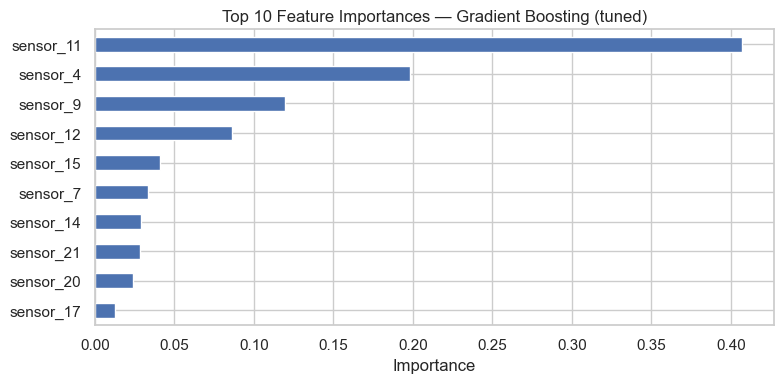

In [17]:
importances = (
    pd.Series(best_gb.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

importances.head(10).sort_values().plot(kind="barh", figsize=(8, 4))
plt.title("Top 10 Feature Importances — Gradient Boosting (tuned)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


The most informative channels are `sensor_11` and `sensor_4`, which correspond — per the C-MAPSS output table in the paper — to the static pressure at the HPC outlet (Ps30) and the total temperature at the LPT outlet (T50 / EGT). Their dominance is consistent with the paper's description of HPC degradation strongly affecting EGT and HPC-side pressures. (Importances come from the tuned Gradient Boosting model; they are shown for interpretation only and play no role in model selection.)


## 11. Final Model Selection

Per-class detail for the two strongest candidates on the validation split:


In [18]:
print("Logistic Regression — validation")
print(classification_report(y_val, y_pred_lr, target_names=CLASS_NAMES))

print("Gradient Boosting — validation")
print(classification_report(y_val, y_pred_gb, target_names=CLASS_NAMES))


Logistic Regression — validation
              precision    recall  f1-score   support

     Healthy       0.86      0.80      0.83      2050
     Warning       0.69      0.71      0.70      1400
    Critical       0.81      0.94      0.87       620

    accuracy                           0.79      4070
   macro avg       0.79      0.82      0.80      4070
weighted avg       0.79      0.79      0.79      4070

Gradient Boosting — validation
              precision    recall  f1-score   support

     Healthy       0.84      0.85      0.85      2050
     Warning       0.73      0.67      0.70      1400
    Critical       0.82      0.93      0.87       620

    accuracy                           0.80      4070
   macro avg       0.80      0.82      0.81      4070
weighted avg       0.80      0.80      0.80      4070



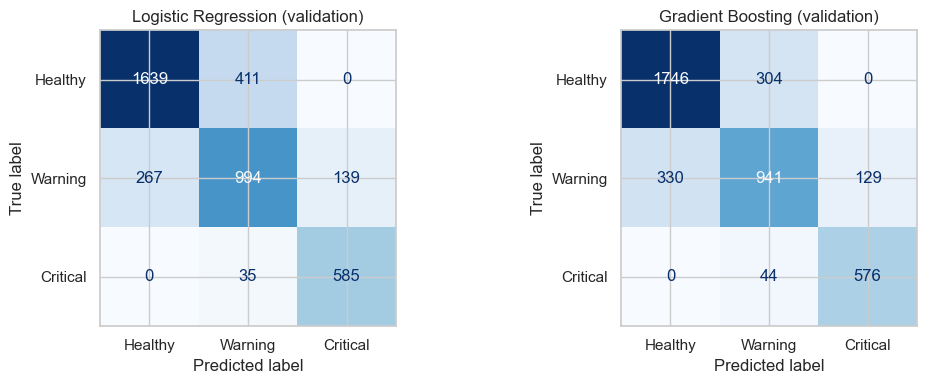

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, y_pred) in zip(
    axes,
    [("Logistic Regression", y_pred_lr), ("Gradient Boosting", y_pred_gb)],
):
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(f"{name} (validation)")

plt.tight_layout()
plt.show()


**Decision — the final model is Logistic Regression.**

Based on the validation results, Logistic Regression is selected because it achieves the **highest Critical Recall (0.94)** — the primary metric for this early-warning objective — while its Balanced Accuracy (0.82) and Macro F1 (0.80) stay within 0.01–0.02 of the best candidates. It is also the simplest and fastest model of the group.

The trade-off, stated explicitly, because the models are close:

- **vs Gradient Boosting:** +0.015 Critical Recall for −0.011 Accuracy — a near-even exchange that favors the primary metric.
- **vs XGBoost:** XGBoost is the strongest all-rounder (Accuracy 0.81, Balanced Accuracy 0.82, Critical Precision 0.82) at a Critical Recall of 0.93, only ~0.017 below Logistic Regression. Under the objective used here — Critical Recall weighted first — we take the extra recall and accept ~0.02 lower accuracy; with equal weighting, XGBoost would be the reasonable pick.
- **Random Forest** is a different operating point entirely: much higher Critical Precision (0.90) but the lowest Critical Recall (0.85).

All candidates make nearly the same kind of error (borderline engines routed to Warning rather than Healthy; no validation Critical engine is predicted Healthy — see Section 13), so this choice is about where to sit on the recall/accuracy trade-off, not about different failure modes.

Selection was made on **validation results only**. The test set has not been touched.


## 12. Final Model Evaluation

The test set is kept separate from model selection and hyperparameter tuning, and it is now used **once** to estimate how the selected model performs on unseen data:

- The selected Logistic Regression is refit on the combined train + validation data — standard practice once validation has served its purpose, so the final model uses all labeled data.
- Test set: the 100 official FD001 test engines, one terminal observation each, labeled from the true RUL file.


In [20]:
X_final_train = pd.concat([X_train, X_val], ignore_index=True)
y_final_train = pd.concat([y_train, y_val], ignore_index=True)
print("Final training set shape:", X_final_train.shape)


Final training set shape: (20631, 16)


In [21]:
# Final model: Logistic Regression, as selected in Section 11
final_model = LogisticRegression(
    solver="lbfgs",
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=GLOBAL_SEED,
)

final_model.fit(X_final_train, y_final_train)
final_test_pred = final_model.predict(X_test)

evaluate(y_test, final_test_pred, "Final model (Logistic Regression)")


,Model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,Final model (Logistic Regression),0.71,0.72,0.724,0.864,0.76


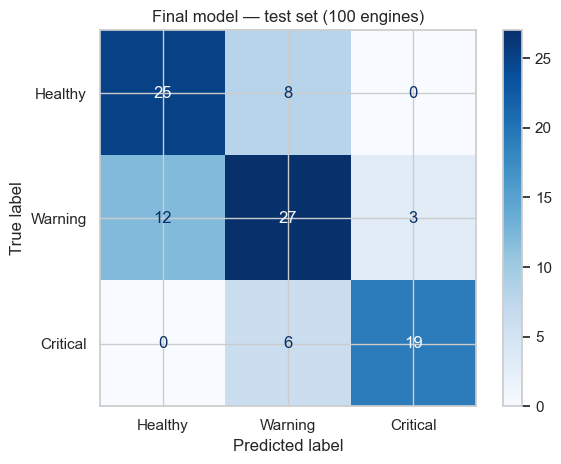

In [22]:
cm = confusion_matrix(y_test, final_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    cmap="Blues", values_format="d"
)
plt.title("Final model — test set (100 engines)")
plt.tight_layout()
plt.show()


In [23]:
print(classification_report(y_test, final_test_pred, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

     Healthy       0.68      0.76      0.71        33
     Warning       0.66      0.64      0.65        42
    Critical       0.86      0.76      0.81        25

    accuracy                           0.71       100
   macro avg       0.73      0.72      0.72       100
weighted avg       0.72      0.71      0.71       100



**Why is the test performance lower than the validation performance?** The drop (Accuracy 0.79 → 0.71; Critical Recall 0.94 → 0.76) is real and is kept as-is. Three factors explain most of it:

1. **Sample size.** The test set has 100 engines, of which only 25 are Critical. Each misclassified engine moves Critical Recall by 0.04.
2. **Different class mix.** The test split is 33% Healthy / 42% Warning / 25% Critical (Section 5), versus 51/34/15 in train and validation — the test engines were truncated earlier in life, so the test distribution concentrates on mid-life states where the Healthy/Warning boundary is hardest.
3. **Metric scale.** Validation metrics average over 4,070 rows; test metrics average over 100 engines.

The error *structure* on test (Section 13) matches the validation structure, so this is a distribution-and-sample-size effect rather than a pipeline defect.


## 13. Error Analysis

From the final test confusion matrix (100 engines; 25 Critical, 42 Warning, 33 Healthy):

| Error type | Count | Early-warning reading |
|---|---|---|
| Critical → Warning | 6 | **Missed Critical engines** — all 6 were still flagged as degraded (Warning), so none was dismissed as healthy |
| Critical → Healthy | 0 | The most dangerous error: not present in this test set |
| Warning → Critical | 3 | Overstatement — an early (possibly premature) alarm |
| Warning → Healthy | 12 | The largest leak: ~29% of degraded engines reported as Healthy |
| Healthy → Critical | 0 | No "panic" alarms from healthy engines |
| Healthy → Warning | 8 | Conservative — extra attention given to healthy engines |

- **Missed Criticals:** 6 of 25. All of them are predicted Warning rather than Healthy, i.e. the system still raises a flag — just not the most urgent one.
- **False Critical alarms:** 3 in total, all from Warning engines — a low alarm burden (Critical Precision 0.86).
- **Healthy ↔ Warning confusion** dominates both directions (8 and 12 engines). This is the expected pattern for ordinal health bands on data where early degradation is weakly visible (Section 2), and it is the main source of the test accuracy gap.

The same structure appears in the validation confusion matrices (Section 11) at larger scale — for example, Logistic Regression on validation sends 35 Critical engines to Warning and 0 to Healthy — so the test errors are a consistent behavior of the model, not test-set noise.

*Interpretation caveat: with 100 test engines, differences of a few engines shift these numbers noticeably; the counts above are best read as a direction, not a precise error rate.*


## 14. Limitations

- **Simulated data.** C-MAPSS trajectories are generated by a thermodynamic simulation with imposed degradation and noise (Section 2). Nothing in this notebook should be taken as measured real-world engine performance.
- **Project-defined thresholds.** The 30/100-cycle boundaries are design assumptions for an early-warning formulation, not values derived from the dataset or from the paper.
- **Small test set.** 100 engines (25 Critical) means the test metrics carry noticeable statistical uncertainty.
- **Single subset / single scenario.** Results apply to FD001 — one operating condition, one (unspecified) HPC degradation mode. Generalization to other subsets or fault modes is not established.
- **Granularity is lost.** Classification discards information that continuous RUL prediction retains: an engine at 31 cycles and one at 100 cycles are both "Warning." The regression notebook preserves that detail.
- **Grouping, not time.** GroupKFold prevents engine overlap across folds but does not model temporal ordering inside a trajectory; the classifier sees single snapshots only.


## 15. Conclusion

We converted the FD001 RUL problem into a 3-class health-state classification with a leakage-controlled, engine-level pipeline and compared four classifier families with class-balanced training and GroupKFold-based tuning.

- **Selected model:** Logistic Regression (refit on train + validation).
- **Validation:** Critical Recall 0.94, Balanced Accuracy 0.82, Macro F1 0.80.
- **Test (single, held-out evaluation):** Accuracy 0.71, Balanced Accuracy 0.72, Macro F1 0.72, Critical Precision 0.86, **Critical Recall 0.76** — 19 of 25 Critical engines detected, 3 false Critical alarms, and no Critical engine dismissed as Healthy.
- The gap between validation and test is explained by the small test size and its mid-life class mix, and the error structure is consistent across both splits.

For this early-warning formulation the headline metric is **Critical Recall**, and the honest reading of the test result is: the system detects the majority of approaching-failure engines at a low false-alarm rate, but a non-trivial minority (6/25) is under-stated as Warning.

This is a benchmark study on simulated data, not a production system. Natural next steps: temporal features (e.g. rolling statistics over the last *k* cycles), decision-threshold calibration on the validation set, and a larger or repeated test evaluation to tighten the statistical uncertainty.
